# CASIA-WEBFACE | Face Verification

#### Christian Budhi S

In [1]:
%load_ext autoreload
%autoreload 2

# Dataset

## Exploratory Data Analysis

In [2]:
import struct
import numpy as np
from collections import Counter
import src.constant as C


idx = {}
with open('dataset/casia-webface/train.idx', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        key, offset = line.split('\t')
        idx[int(key)] = int(offset)

labels = []
with open('dataset/casia-webface/train.rec', 'rb') as f:
    for offset in idx.values():
        f.seek(offset)
        f.read(C._IR_BUFFER)
        label = struct.unpack(C._IR_FORMAT, f.read(C._IR_SIZE))[1]
        labels.append(int(label))

counts      = Counter(labels)
per_person  = list(counts.values())

print(f"  Total image    : {len(labels):>10,}")
print(f"  Total people   : {len(counts):>10,}")
print(f"  Min per person : {min(per_person):>10,}")
print(f"  Max per person : {max(per_person):>10,}")
print(f"  Avg per person : {np.mean(per_person):>10.1f}")
print(f"  Median         : {np.median(per_person):>10.1f}")

print("\n  Top 5 most frequent identities:")
for pid, cnt in counts.most_common(5):
    print(f"    id {pid:>6} :  {cnt} photos")

print("\n  Bottom 5 least frequent identities:")
for pid, cnt in counts.most_common()[:-6:-1]:
    print(f"    id {pid:>6} :  {cnt} photos")

  Total image    :    501,196
  Total people   :     10,572
  Min per person :          2
  Max per person :     10,588
  Avg per person :       47.4
  Median         :       27.0

  Top 5 most frequent identities:
    id      0 :  10588 photos
    id    819 :  802 photos
    id   3410 :  744 photos
    id    138 :  710 photos
    id   1321 :  651 photos

  Bottom 5 least frequent identities:
    id   9282 :  2 photos
    id   4383 :  4 photos
    id   4328 :  4 photos
    id   9804 :  5 photos
    id   4447 :  5 photos


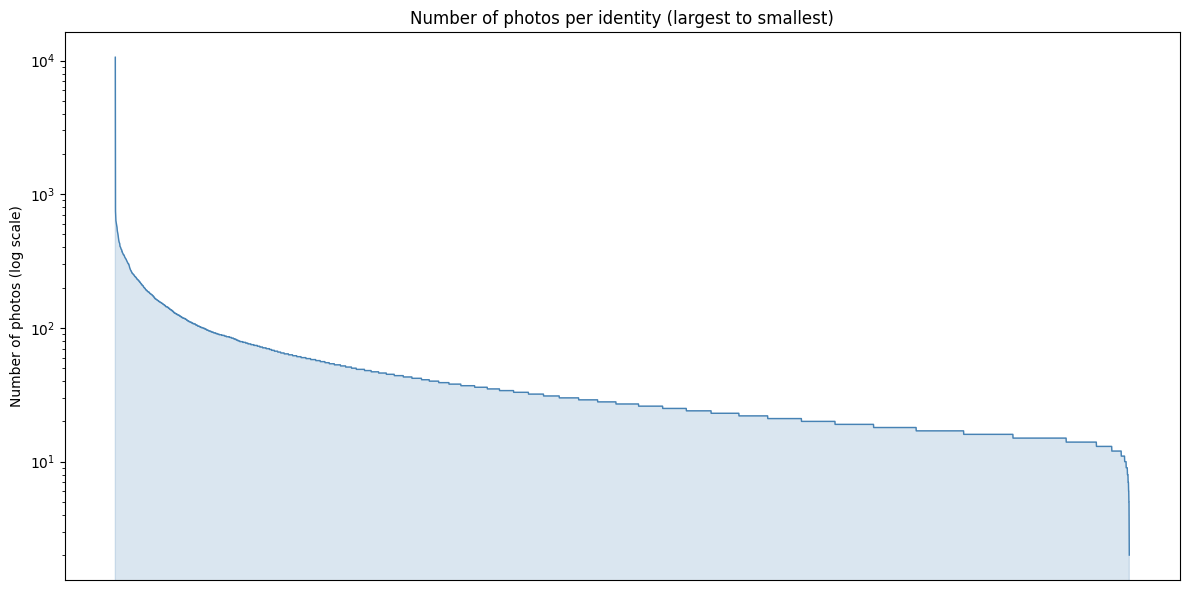

In [3]:
import matplotlib.pyplot as plt

sorted_counts = sorted(counts.values(), reverse=True)

plt.figure(figsize=(12, 6))
plt.plot(sorted_counts, linewidth=1, color='steelblue')
plt.fill_between(range(len(sorted_counts)), sorted_counts, alpha=0.2, color='steelblue')
plt.title('Number of photos per identity (largest to smallest)')
plt.yscale('log')
plt.ylabel('Number of photos (log scale)')
plt.xticks([])
plt.tight_layout()
plt.show()

In [4]:
sorted_counts = sorted(counts.values(), reverse=True)

low_thresh  = int(np.percentile(sorted_counts, 10))
high_thresh = int(np.percentile(sorted_counts, 80))

print(f"Keep identities with photos between {high_thresh} and {low_thresh}")
print(f"Identities kept  : {sum(low_thresh <= c <= high_thresh for c in counts.values()):,}  [{sum(c if low_thresh <= c <= high_thresh else 0 for c in counts.values())}]")
print(f"Identities total : {len(counts):,} [{sum(c for c in counts.values())}]")

Keep identities with photos between 57 and 15
Identities kept  : 7,824  [214927]
Identities total : 10,572 [501196]


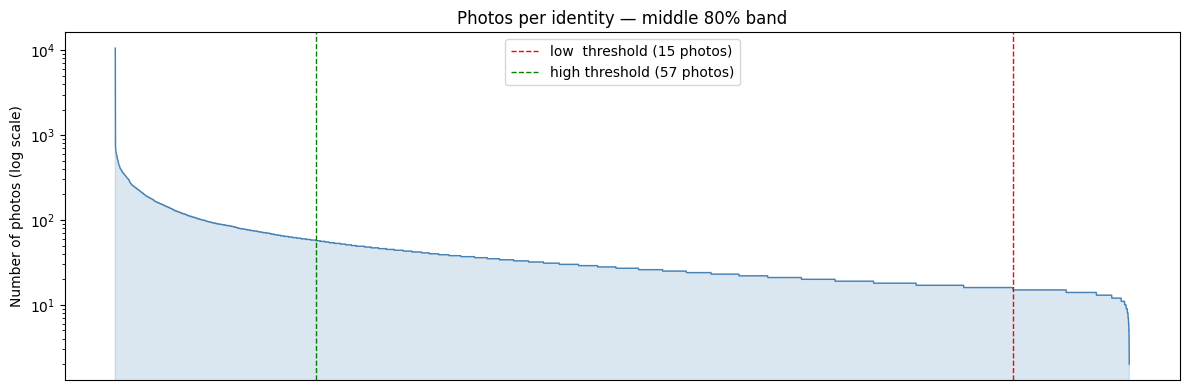

In [5]:
high_x = next(i for i, c in enumerate(sorted_counts) if c <= high_thresh)
low_x  = next(i for i, c in enumerate(sorted_counts) if c <= low_thresh)

plt.figure(figsize=(12, 4))
plt.plot(sorted_counts, linewidth=1, color='steelblue')
plt.fill_between(range(len(sorted_counts)), sorted_counts, alpha=0.2, color='steelblue')
plt.yscale('log')
plt.xticks([])
plt.axvline(low_x,  color='red',   linewidth=1, linestyle='--', label=f'low  threshold ({low_thresh} photos)')
plt.axvline(high_x, color='green', linewidth=1, linestyle='--', label=f'high threshold ({high_thresh} photos)')
plt.legend(loc='upper center')
plt.title('Photos per identity — middle 80% band')
plt.ylabel('Number of photos (log scale)')
plt.tight_layout()
plt.show()

In [6]:
train_ids = {pid for pid, cnt in counts.items() if low_thresh <= cnt <= high_thresh}
test_ids = {pid for pid, cnt in counts.items() if cnt <= low_thresh or cnt >= high_thresh}

## Reproducibility

In [7]:
import random, os
import torch
import lightning as L

SEED = 42

L.seed_everything(SEED)

Seed set to 42


42

## Data Inspection

In [8]:
from torchvision import transforms
from src.datamodule import *


train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

EVAL_BINS = {
    'lfw'      : 'dataset/eval/lfw.bin',
    'cfp_fp'   : 'dataset/eval/cfp_fp.bin',
    'agedb_30' : 'dataset/eval/agedb_30.bin',
    'sllfw'    : 'dataset/eval/sllfw.bin',
    'talfw'    : 'dataset/eval/talfw.bin',
}

dm = FaceDataModule(
    rec_path         = 'dataset/casia-webface/train.rec',
    idx_path         = 'dataset/casia-webface/train.idx',
    train_ids        = train_ids,   # from your filtering cell
    test_ids         = test_ids,
    eval_bins        = EVAL_BINS,
    train_transform  = train_tf,
    val_transform    = val_tf,
    batch_size       = 64,
    num_workers      = 4,
    seed             = SEED,
)
dm.setup()

print(f"Train samples   : {len(dm.train_ds):,}")
print(f"Rec test samples: {len(dm.rec_test_ds):,}")
for name, ds in dm.bin_test_ds.items():
    print(f"  {name:12}: {len(ds):,} pairs")

Seed set to 42


Train samples   : 214,927
Rec test samples: 297,273
  lfw         : 6,000 pairs
  cfp_fp      : 7,000 pairs
  agedb_30    : 6,000 pairs
  sllfw       : 6,000 pairs
  talfw       : 6,000 pairs


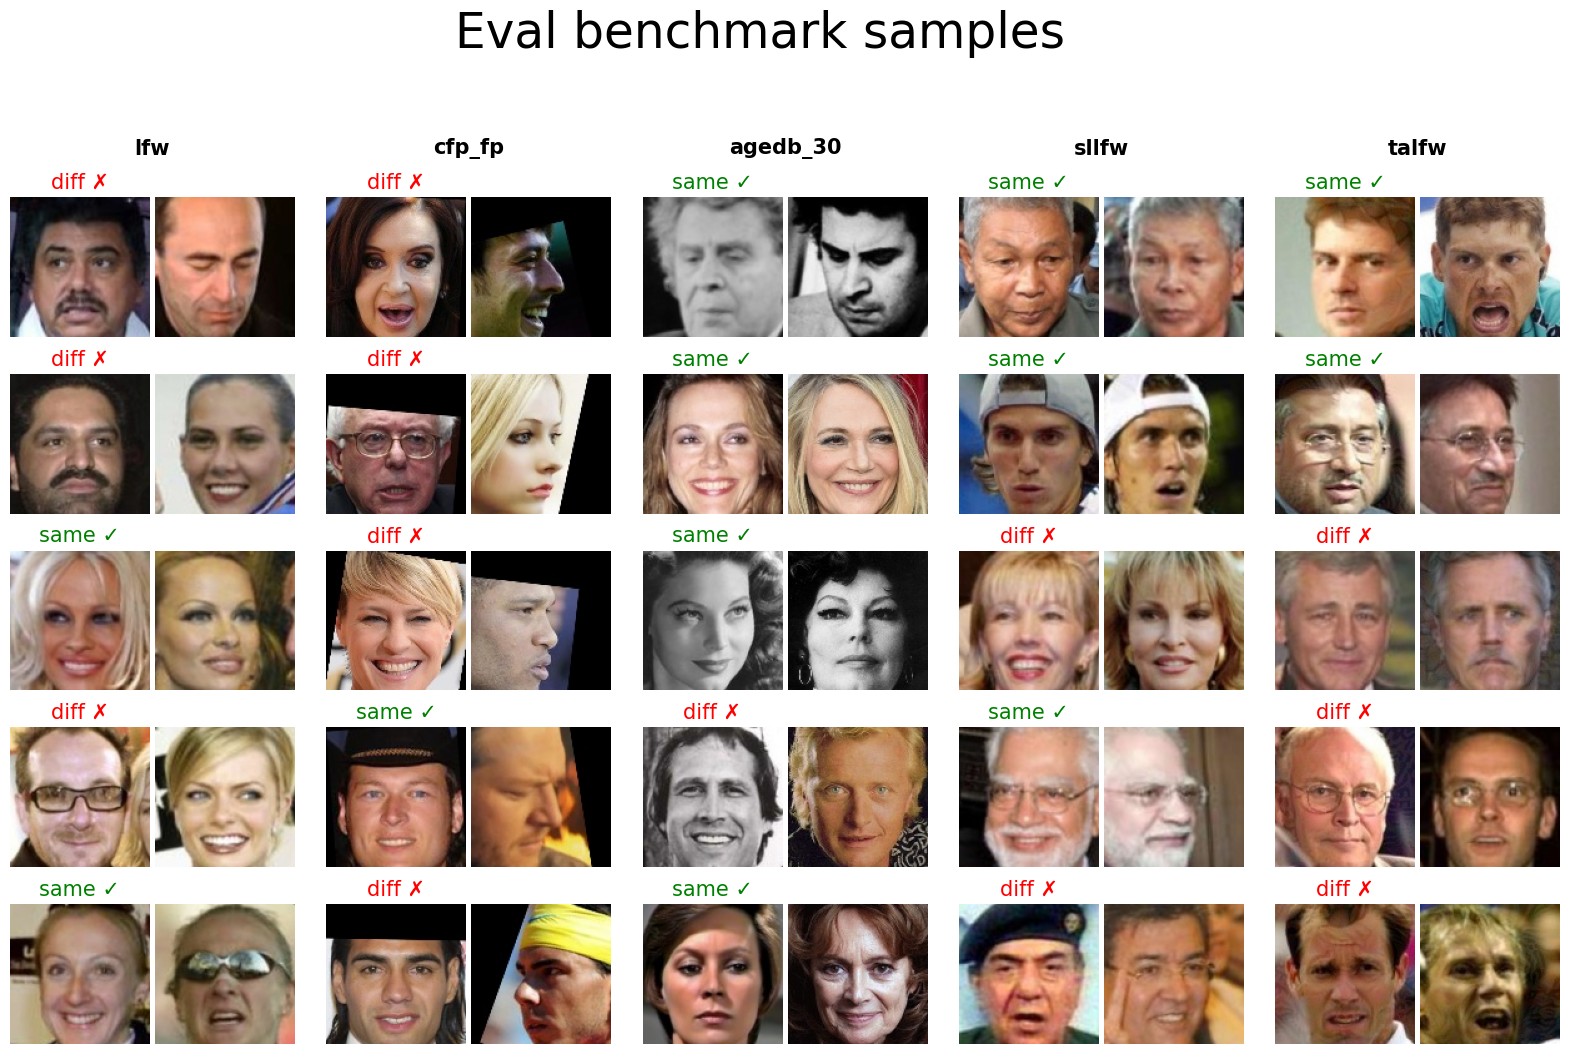

In [9]:
import matplotlib.gridspec as gridspec

n_pairs  = 5
datasets = list(dm.bin_test_ds.items())
n_ds     = len(datasets)

col_widths = []
for i in range(n_ds):
    col_widths += [1, 1]
    if i < n_ds - 1:
        col_widths.append(0.15)

# extra row at top for dataset titles, kept short via height_ratios
fig = plt.figure(figsize=(n_ds * 4, n_pairs * 2.2 + 0.5))
gs  = gridspec.GridSpec(
    n_pairs + 1, len(col_widths),
    width_ratios  = col_widths,
    height_ratios = [0.01] + [1] * n_pairs,
    wspace=0.05, hspace=0.3
)

def to_np(t):
    t = t * 0.5 + 0.5
    return t.permute(1, 2, 0).numpy().clip(0, 1)

for ds_idx, (name, ds) in enumerate(datasets):
    base_col = ds_idx * 3

    # title axis spans both image columns in row 0
    ax_title = fig.add_subplot(gs[0, base_col:base_col + 2])
    ax_title.set_title(name, fontsize=3 * n_pairs, fontweight='bold', pad=2)
    ax_title.axis('off')

    indices = random.sample(range(len(ds)), n_pairs)
    for row, idx in enumerate(indices):
        img_a, img_b, same = ds[idx]
        label = 'same ✓' if same else 'diff ✗'
        color = 'green'  if same else 'red'

        ax_a = fig.add_subplot(gs[row + 1, base_col])
        ax_b = fig.add_subplot(gs[row + 1, base_col + 1])

        ax_a.imshow(to_np(img_a))
        ax_b.imshow(to_np(img_b))
        ax_a.set_title(label, fontsize=3 * n_pairs, color=color)
        ax_a.axis('off')
        ax_b.axis('off')

plt.suptitle('Eval benchmark samples', fontsize=7 * n_pairs, y=1.01)
plt.show()

In [10]:
for fold in range(5):
    dm = KFoldFaceDataModule(
        rec_path        = 'dataset/casia-webface/train.rec',
        idx_path        = 'dataset/casia-webface/train.idx',
        train_ids       = train_ids,
        test_ids        = test_ids,
        eval_bins       = EVAL_BINS,
        train_transform = train_tf,
        val_transform   = val_tf,
        batch_size      = 64,
        num_workers     = 4,
        seed            = SEED,
        n_folds         = 5,
        fold            = fold,
    )
    dm.setup()

    print(f"Fold {fold+1}/5")
    print(f"  train : {len(dm.train_ds):>10,}")
    print(f"  val   : {len(dm.val_ds):>10,}")

Seed set to 42
Seed set to 42


Fold 1/5
  train :    171,941
  val   :     42,986


Seed set to 42


Fold 2/5
  train :    171,941
  val   :     42,986


Seed set to 42


Fold 3/5
  train :    171,942
  val   :     42,985


Seed set to 42


Fold 4/5
  train :    171,942
  val   :     42,985
Fold 5/5
  train :    171,942
  val   :     42,985
